In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelBinarizer

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the Iris dataset
iris_df = pd.read_csv('/content/iris (1) (2).csv')

# Display the first few rows and info to understand the data
print("Iris Dataset Head:")
display(iris_df.head())
print("\nIris Dataset Info:")
iris_df.info()

# Prepare features (X) and target (y)
X_iris = iris_df.drop('species', axis=1) # Assuming 'species' is the target column
y_iris = iris_df['species']

# Split the data into training and testing sets (80% train, 20% test)
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

print(f"\nIris Training data shape: {X_train_iris.shape}, Testing data shape: {X_test_iris.shape}")

Iris Dataset Head:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Iris Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Iris Training data shape: (120, 4), Testing data shape: (30, 4)


Iris SVM (RBF Kernel) Accuracy: 0.9667


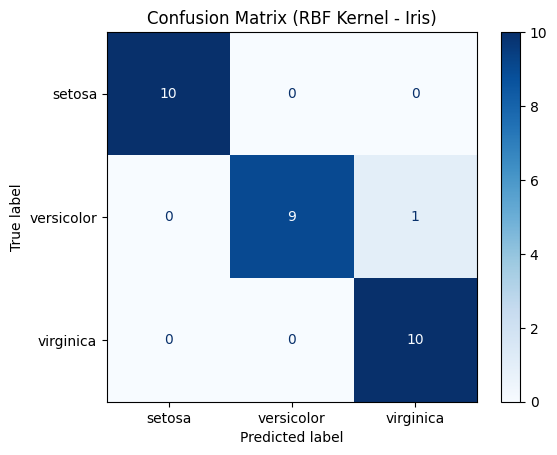

In [3]:
# Build SVM classifier with RBF kernel
svm_rbf_iris = SVC(kernel='rbf', random_state=42)
svm_rbf_iris.fit(X_train_iris, y_train_iris)

# Predict on the test data
y_pred_rbf_iris = svm_rbf_iris.predict(X_test_iris)

# Display accuracy score
accuracy_rbf_iris = accuracy_score(y_test_iris, y_pred_rbf_iris)
print(f"Iris SVM (RBF Kernel) Accuracy: {accuracy_rbf_iris:.4f}")

# Display confusion matrix
cm_rbf_iris = confusion_matrix(y_test_iris, y_pred_rbf_iris)
disp_rbf_iris = ConfusionMatrixDisplay(confusion_matrix=cm_rbf_iris, display_labels=svm_rbf_iris.classes_)
disp_rbf_iris.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (RBF Kernel - Iris)')
plt.show()

Iris SVM (Linear Kernel) Accuracy: 1.0000


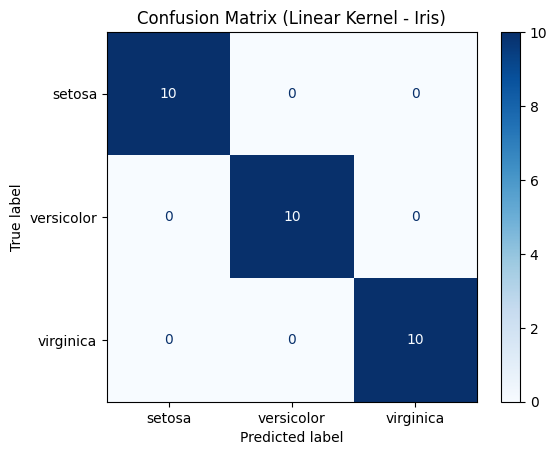

In [4]:
# Build SVM classifier with Linear kernel
svm_linear_iris = SVC(kernel='linear', random_state=42)
svm_linear_iris.fit(X_train_iris, y_train_iris)

# Predict on the test data
y_pred_linear_iris = svm_linear_iris.predict(X_test_iris)

# Display accuracy score
accuracy_linear_iris = accuracy_score(y_test_iris, y_pred_linear_iris)
print(f"Iris SVM (Linear Kernel) Accuracy: {accuracy_linear_iris:.4f}")

# Display confusion matrix
cm_linear_iris = confusion_matrix(y_test_iris, y_pred_linear_iris)
disp_linear_iris = ConfusionMatrixDisplay(confusion_matrix=cm_linear_iris, display_labels=svm_linear_iris.classes_)
disp_linear_iris.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Linear Kernel - Iris)')
plt.show()

In [5]:
# Load the drug dataset (assuming it's the 'Letter-recognition' dataset)
drug_df = pd.read_csv('/content/drug.csv')

# Display the first few rows and info to understand the data
print("Drug Dataset Head:")
display(drug_df.head())
print("\nDrug Dataset Info:")
drug_df.info()

# Prepare features (X) and target (y)
# Assuming the last column 'Drug' is the target variable for classification
X_drug = drug_df.drop('Drug', axis=1)
y_drug = drug_df['Drug']

# Convert categorical features to numerical using one-hot encoding if present
X_drug = pd.get_dummies(X_drug, drop_first=True)

# Split the data into training and testing sets (80% train, 20% test)
X_train_drug, X_test_drug, y_train_drug, y_test_drug = train_test_split(
    X_drug, y_drug, test_size=0.2, random_state=42, stratify=y_drug
)

print(f"\nDrug Training data shape: {X_train_drug.shape}, Testing data shape: {X_test_drug.shape}")

Drug Dataset Head:


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY



Drug Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB

Drug Training data shape: (160, 6), Testing data shape: (40, 6)


Drug SVM (RBF Kernel) Accuracy: 0.6750


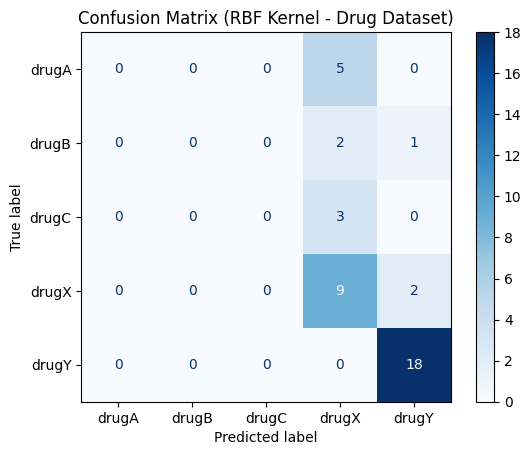

In [6]:
# Build SVM classifier with RBF kernel
# Set probability=True to enable `predict_proba` for ROC curve
svm_rbf_drug = SVC(kernel='rbf', probability=True, random_state=42)
svm_rbf_drug.fit(X_train_drug, y_train_drug)

# Predict on the test data
y_pred_rbf_drug = svm_rbf_drug.predict(X_test_drug)

# Display accuracy score
accuracy_rbf_drug = accuracy_score(y_test_drug, y_pred_rbf_drug)
print(f"Drug SVM (RBF Kernel) Accuracy: {accuracy_rbf_drug:.4f}")

# Display confusion matrix
cm_rbf_drug = confusion_matrix(y_test_drug, y_pred_rbf_drug)
disp_rbf_drug = ConfusionMatrixDisplay(confusion_matrix=cm_rbf_drug, display_labels=svm_rbf_drug.classes_)
disp_rbf_drug.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (RBF Kernel - Drug Dataset)')
plt.show()

### ROC Curve and AUC Score for Drug Dataset

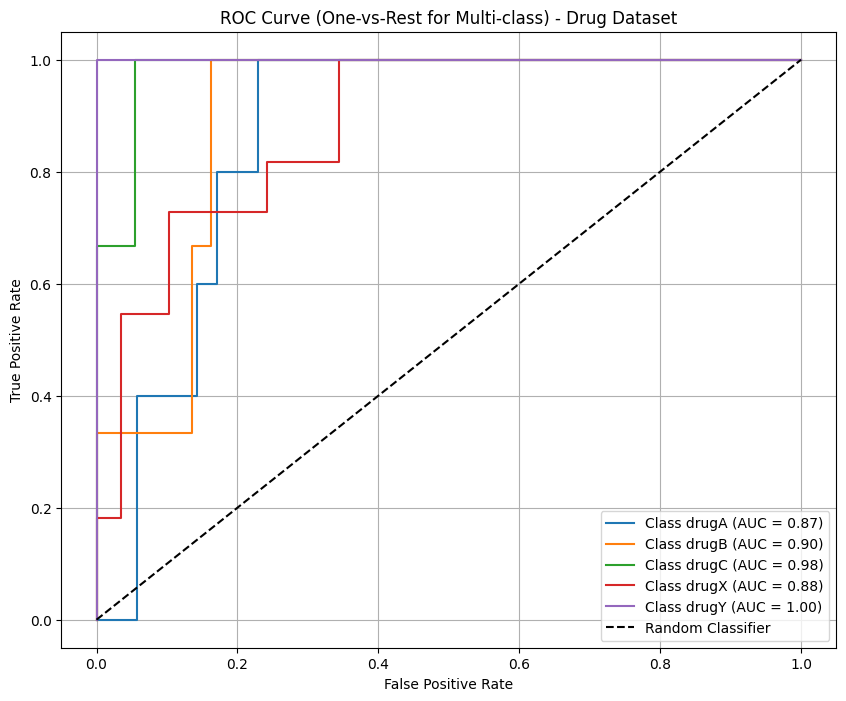

Micro-averaged AUC score: 0.9517
Macro-averaged AUC score: 0.9271


In [7]:
# Get probability scores for each class
y_proba_rbf_drug = svm_rbf_drug.predict_proba(X_test_drug)

# Binarize the true labels for multi-class ROC
label_binarizer = LabelBinarizer()
y_test_binarized = label_binarizer.fit_transform(y_test_drug)

# Plot ROC curve for each class
plt.figure(figsize=(10, 8))
for i, class_name in enumerate(label_binarizer.classes_):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_proba_rbf_drug[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {class_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest for Multi-class) - Drug Dataset')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Calculate and display Macro-averaged AUC score
micro_fpr, micro_tpr, _ = roc_curve(y_test_binarized.ravel(), y_proba_rbf_drug.ravel())
micro_auc = auc(micro_fpr, micro_tpr)
print(f"Micro-averaged AUC score: {micro_auc:.4f}")

# Calculate and display Macro-averaged AUC score (average of individual class AUCs)
macro_auc_scores = []
for i in range(len(label_binarizer.classes_)):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_proba_rbf_drug[:, i])
    macro_auc_scores.append(auc(fpr, tpr))

print(f"Macro-averaged AUC score: {np.mean(macro_auc_scores):.4f}")